In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TIME_OFFSET = 10800

In [3]:
from pathlib import Path


def combine_compromised_scada_attack_logs(log_root="../data/attack/compromised-scada/attack logs"):
    log_root = Path(log_root)
    csv_files = sorted(log_root.glob("*/*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No compromised-SCADA attack logs found under: {log_root}")

    frames = []
    for csv_file in csv_files:
        frame = pd.read_csv(csv_file)
        frame["source_file"] = csv_file.name
        frames.append(frame)

    combined = pd.concat(frames, ignore_index=True)
    combined["Timestamp"] = pd.to_datetime(combined["Timestamp"], errors="coerce")
    combined = combined.dropna(subset=["Timestamp"]).copy()
    combined = combined.sort_values("Timestamp")

    print(f"Combined compromised-SCADA attack log files: {len(csv_files)}")
    print(f"Combined rows: {len(combined)}")
    print(f"Start timestamp: {combined['Timestamp'].min()}")
    print(f"End timestamp:   {combined['Timestamp'].max()}")

    return combined


combined_compromised_scada_logs = combine_compromised_scada_attack_logs()

# cscada = pd.read_csv("../train/cscada_attack_ssw_analysis.csv", usecols=["frame.time_epoch"])
# cscada_epoch = pd.to_numeric(cscada["frame.time_epoch"], errors="coerce").dropna()
# cscada_utc = pd.to_datetime(cscada_epoch + TIME_OFFSET, unit="s", errors="coerce").dropna()
# print("cscada_attack_ssw_analysis.csv")
# print(f"  adjusted start: {cscada_utc.min()}")
# print(f"  adjusted end:   {cscada_utc.max()}")

Combined compromised-SCADA attack log files: 21
Combined rows: 1279853
Start timestamp: 2023-03-12 16:12:27.761000
End timestamp:   2023-03-22 03:41:25.376000


In [4]:
import ipaddress
from pathlib import Path


def extract_and_plot_ip_window(
    input_csv,
    target_ip,
    target_timestamp,
    output_csv,
    seconds_each_side=20,
    steps_each_side=None,
    time_offset_seconds=TIME_OFFSET,
):
    """
    Filter packets for target_ip around target_timestamp (±seconds_each_side seconds),
    save filtered packets to CSV, and plot RX/TX packet counts per 1-second aggregate.

    target_timestamp format example: "2023-03-12 16:12:27.761"
    The plot uses 1-second aggregates centered on target_timestamp.
    """
    ipaddress.ip_address(target_ip)

    if steps_each_side is not None:
        seconds_each_side = steps_each_side

    input_path = Path(input_csv)
    if not input_path.exists():
        raise FileNotFoundError(f"Input CSV not found: {input_path}")

    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    required_cols = ["ip.src", "ip.dst", "frame.time_epoch"]
    df = pd.read_csv(input_path, usecols=required_cols)

    frame_epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[frame_epoch.notna()].copy()
    df["aligned_epoch"] = frame_epoch[frame_epoch.notna()] + float(time_offset_seconds)
    df["aligned_ts"] = pd.to_datetime(df["aligned_epoch"], unit="s", errors="coerce")

    target_ts = pd.to_datetime(target_timestamp, errors="raise")

    src = df["ip.src"].fillna("").astype(str)
    dst = df["ip.dst"].fillna("").astype(str)
    ip_df = df[(src == target_ip) | (dst == target_ip)].copy()

    if ip_df.empty:
        ip_df.to_csv(output_path, index=False)
        print(f"No packets found for IP {target_ip}. Saved empty result to: {output_path}")
        return ip_df

    ip_df["abs_delta_s"] = (ip_df["aligned_ts"] - target_ts).abs().dt.total_seconds()
    nearest_idx = ip_df["abs_delta_s"].idxmin()
    nearest_row = ip_df.loc[nearest_idx]
    nearest_cols = [
        c
        for c in [
            "aligned_ts",
            "frame.time_epoch",
            "ip.src",
            "ip.dst",
            "frame.len",
            "modbus.func_code",
            "modbus.reference_num",
            "modbus.exception_code",
        ]
        if c in ip_df.columns
    ]

    window_start = target_ts - pd.Timedelta(seconds=seconds_each_side)
    window_end = target_ts + pd.Timedelta(seconds=seconds_each_side)
    window_df = ip_df[(ip_df["aligned_ts"] >= window_start) & (ip_df["aligned_ts"] <= window_end)].copy()
    window_df = window_df.sort_values("aligned_ts")
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    target_second = target_ts.floor("s")
    plot_bins = pd.date_range(
        start=target_second - pd.Timedelta(seconds=seconds_each_side),
        end=target_second + pd.Timedelta(seconds=seconds_each_side),
        freq="s",
    )

    tx_counts = (
        window_df[window_df["ip.src"].astype(str) == target_ip]
        .groupby("second_bin")
        .size()
        .reindex(plot_bins, fill_value=0)
    )
    rx_counts = (
        window_df[window_df["ip.dst"].astype(str) == target_ip]
        .groupby("second_bin")
        .size()
        .reindex(plot_bins, fill_value=0)
    )
    rel_x = (plot_bins - target_second).total_seconds().astype(int)

    window_df.to_csv(output_path, index=False)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, tx_counts.values, label="TX (ip.src == target_ip)", marker="o")
    plt.plot(rel_x, rx_counts.values, label="RX (ip.dst == target_ip)", marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("Packet count")
    plt.title(f"Packets for {target_ip} around {target_timestamp} (±{seconds_each_side} seconds)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("Bin size: 1.000000 seconds")
    print(f"Input rows: {len(df)}")
    print(f"Rows for IP: {len(ip_df)}")
    print(f"Rows in ±{seconds_each_side} second window: {len(window_df)}")

    print("Nearest packet to target timestamp for this IP:")
    print(nearest_row[nearest_cols].to_string())
    print(f"Absolute time delta (s): {nearest_row['abs_delta_s']:.6f}")

    if window_df.empty:
        min_ts = ip_df["aligned_ts"].min()
        max_ts = ip_df["aligned_ts"].max()
        print("No rows in requested window.")
        print(f"IP time range in this CSV: {min_ts} -> {max_ts}")

    print(f"Saved filtered packets to: {output_path}")

    return window_df


# Example:
# extract_and_plot_ip_window(
#     input_csv="../train/cscada_attack_ssw.csv",
#     target_ip="185.175.0.5",
#     target_timestamp="2023-03-12 16:12:27.761",
#     output_csv="obs/packets_185.175.0.5_around_event.csv",
#     seconds_each_side=20,
# )

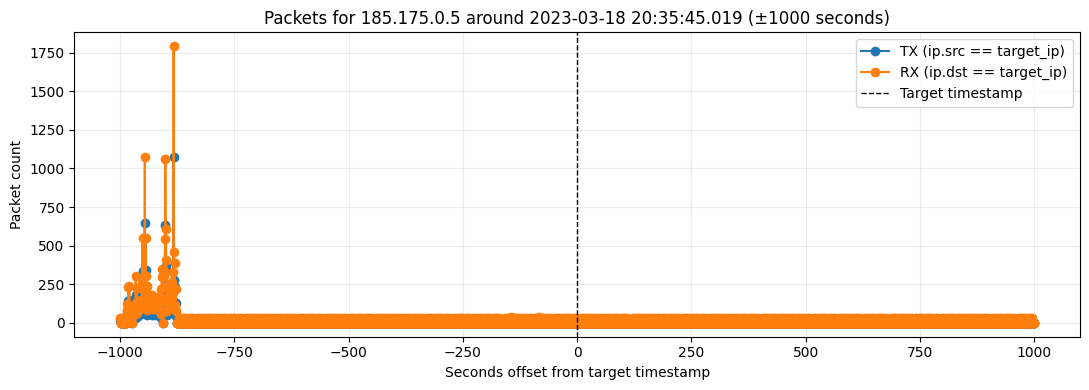

Bin size: 1.000000 seconds
Input rows: 1000000
Rows for IP: 376714
Rows in ±1000 second window: 53141
Nearest packet to target timestamp for this IP:
aligned_ts          2023-03-18 20:35:43.961415052
frame.time_epoch                1679160943.961415
ip.src                                185.175.0.3
ip.dst                                185.175.0.5
Absolute time delta (s): 1.057585
Saved filtered packets to: obs/packets_185.175.0.5_around_event.csv


,frame.time_epoch,ip.src,ip.dst,aligned_epoch,aligned_ts,abs_delta_s,second_bin
12064,1.679160e+09,185.175.0.3,185.175.0.5,1.679171e+09,2023-03-18 20:19:05.109796047,999.909204,2023-03-18 20:19:05
12065,1.679160e+09,185.175.0.5,185.175.0.3,1.679171e+09,2023-03-18 20:19:05.109833002,999.909167,2023-03-18 20:19:05
12066,1.679160e+09,185.175.0.3,185.175.0.5,1.679171e+09,2023-03-18 20:19:05.109858990,999.909141,2023-03-18 20:19:05
12067,1.679160e+09,185.175.0.3,185.175.0.5,1.679171e+09,2023-03-18 20:19:05.110326052,999.908674,2023-03-18 20:19:05
12068,1.679160e+09,185.175.0.5,185.175.0.3,1.679171e+09,2023-03-18 20:19:05.110348940,999.908651,2023-03-18 20:19:05
...,...,...,...,...,...,...,...
109323,1.679162e+09,185.175.0.5,185.175.0.3,1.679173e+09,2023-03-18 20:52:21.629760981,996.610761,2023-03-18 20:52:21
109324,1.679162e+09,185.175.0.3,185.175.0.5,1.679173e+09,2023-03-18 20:52:21.629782915,996.610783,2023-03-18 20:52:21
109325,1.679162e+09,185.175.0.3,185.175.0.5,1.679173e+09,2023-03-18 20:52:21.629898071,996.610898,2023-03-18 20:52:21
109326,1.679162e+09,185.175.0.5,185.175.0.3,1.679173e+09,2023-03-18 20:52:21.630083084,996.611083,2023-03-18 20:52:21


In [6]:
extract_and_plot_ip_window(
    input_csv="../train/chunks/csc_9.csv",
    target_ip="185.175.0.5",
    target_timestamp="2023-03-18 20:35:45.019",
    output_csv="obs/packets_185.175.0.5_around_event.csv",
    steps_each_side=1000,
)

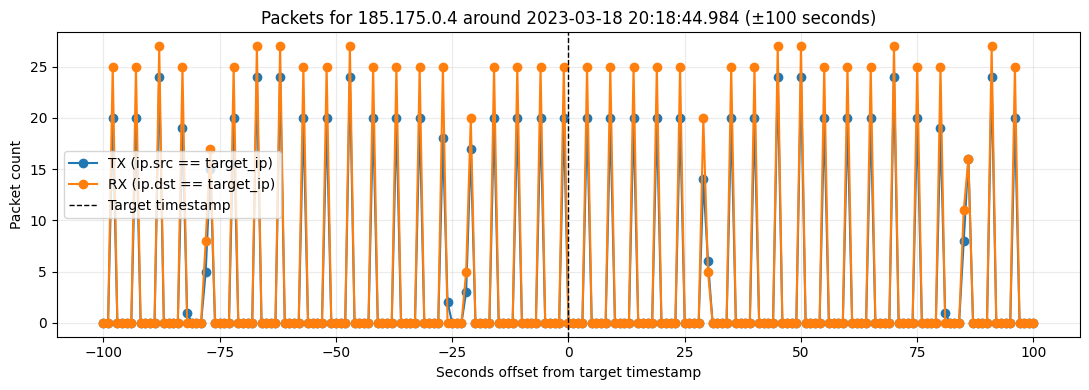

Bin size: 1.000000 seconds
Input rows: 1156957
Rows for IP: 351418
Rows in ±100 second window: 1809
Nearest packet to target timestamp for this IP:
aligned_ts               2023-03-18 20:18:43.489204884
frame.time_epoch                     1679159923.489205
ip.src                                     185.175.0.4
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.reference_num                               NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.494795
Saved filtered packets to: obs/packets_185.175.0.4_around_event.csv


,frame.time_epoch,frame.len,ip.src,ip.dst,modbus.func_code,modbus.reference_num,modbus.read_reference_num,modbus.write_reference_num,modbus.word_cnt,modbus.read_word_cnt,...,modbus.exception_code,modbus.response_time,modbus.request_frame,modbus.regnum16,modbus.regval_uint16,modbus.regval_float,aligned_epoch,aligned_ts,abs_delta_s,second_bin
15445,1.679160e+09,74,185.175.0.3,185.175.0.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:17:06.597371101,98.386629,2023-03-18 20:17:06
15446,1.679160e+09,74,185.175.0.4,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:17:06.597408056,98.386592,2023-03-18 20:17:06
15447,1.679160e+09,66,185.175.0.3,185.175.0.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:17:06.597435951,98.386564,2023-03-18 20:17:06
15448,1.679160e+09,78,185.175.0.3,185.175.0.4,3.0,8.0,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:17:06.597548008,98.386452,2023-03-18 20:17:06
15449,1.679160e+09,66,185.175.0.4,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:17:06.597565889,98.386434,2023-03-18 20:17:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35150,1.679160e+09,76,185.175.0.4,185.175.0.3,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0.006917,35146.0,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:20:20.267155886,95.283156,2023-03-18 20:20:20
35151,1.679160e+09,66,185.175.0.3,185.175.0.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:20:20.267182112,95.283182,2023-03-18 20:20:20
35152,1.679160e+09,66,185.175.0.3,185.175.0.4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:20:20.267307043,95.283307,2023-03-18 20:20:20
35154,1.679160e+09,66,185.175.0.4,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:20:20.281199932,95.297200,2023-03-18 20:20:20


In [11]:
extract_and_plot_ip_window(
    input_csv="../train/cscada_attack_ssw.csv",
    target_ip="185.175.0.4",
    target_timestamp="2023-03-18 20:18:44.984",
    output_csv="obs/packets_185.175.0.4_around_event.csv",
    steps_each_side=100,
)

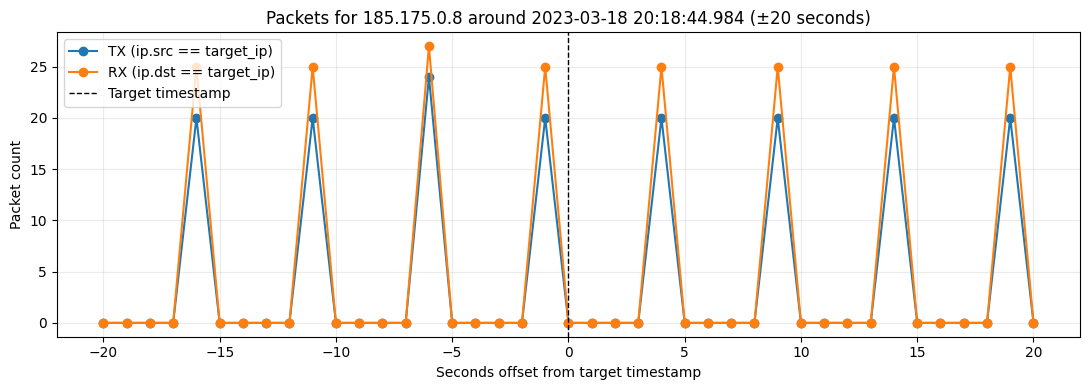

Bin size: 1.000000 seconds
Input rows: 1156957
Rows for IP: 355577
Rows in ±20 second window: 366
Nearest packet to target timestamp for this IP:
aligned_ts               2023-03-18 20:18:43.561216116
frame.time_epoch                     1679159923.561216
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.reference_num                               NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.422784
Saved filtered packets to: obs/packets_185.175.0.8_around_event.csv


,frame.time_epoch,frame.len,ip.src,ip.dst,modbus.func_code,modbus.reference_num,modbus.read_reference_num,modbus.write_reference_num,modbus.word_cnt,modbus.read_word_cnt,...,modbus.exception_code,modbus.response_time,modbus.request_frame,modbus.regnum16,modbus.regval_uint16,modbus.regval_float,aligned_epoch,aligned_ts,abs_delta_s,second_bin
17767,1.679160e+09,74,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:18:28.157303095,16.826697,2023-03-18 20:18:28
17768,1.679160e+09,74,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:18:28.157332897,16.826667,2023-03-18 20:18:28
17769,1.679160e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:18:28.157355070,16.826645,2023-03-18 20:18:28
17770,1.679160e+09,78,185.175.0.3,185.175.0.8,3.0,8.0,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:18:28.157452106,16.826548,2023-03-18 20:18:28
17771,1.679160e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:18:28.157469034,16.826531,2023-03-18 20:18:28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18806,1.679160e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:19:03.896085978,18.912086,2023-03-18 20:19:03
18807,1.679160e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:19:03.896200895,18.912201,2023-03-18 20:19:03
18808,1.679160e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:19:03.897185087,18.913185,2023-03-18 20:19:03
18809,1.679160e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679171e+09,2023-03-18 20:19:03.917188883,18.933189,2023-03-18 20:19:03


In [8]:
extract_and_plot_ip_window(
    input_csv="../train/cscada_attack_ssw.csv",
    target_ip="185.175.0.8",
    target_timestamp="2023-03-18 20:18:44.984",
    output_csv="obs/packets_185.175.0.8_around_event.csv",
    steps_each_side=20,
)

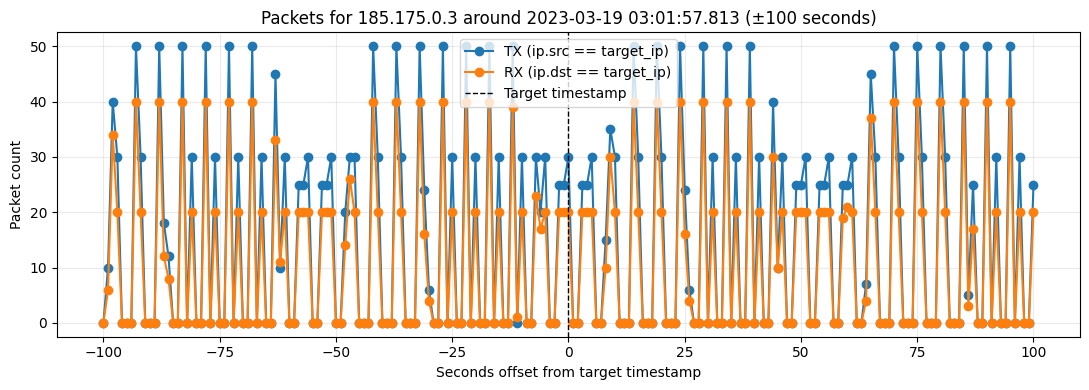

Bin size: 1.000000 seconds
Input rows: 1156957
Rows for IP: 1136224
Rows in ±100 second window: 5517
Nearest packet to target timestamp for this IP:
aligned_ts               2023-03-19 03:01:57.562952995
frame.time_epoch                     1679184117.562953
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.reference_num                               NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.250047
Saved filtered packets to: obs/packets_185.175.0.3_around_event.csv


,frame.time_epoch,frame.len,ip.src,ip.dst,modbus.func_code,modbus.reference_num,modbus.read_reference_num,modbus.write_reference_num,modbus.word_cnt,modbus.read_word_cnt,...,modbus.exception_code,modbus.response_time,modbus.request_frame,modbus.regnum16,modbus.regval_uint16,modbus.regval_float,aligned_epoch,aligned_ts,abs_delta_s,second_bin
899257,1.679184e+09,74,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:00:18.962999105,98.850001,2023-03-19 03:00:18
899258,1.679184e+09,74,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:00:18.963033915,98.849966,2023-03-19 03:00:18
899259,1.679184e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:00:18.963059902,98.849940,2023-03-19 03:00:18
899260,1.679184e+09,78,185.175.0.3,185.175.0.8,3.0,8.0,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:00:18.963167906,98.849832,2023-03-19 03:00:18
899261,1.679184e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:00:18.963184118,98.849816,2023-03-19 03:00:18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904911,1.679184e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:03:37.728529930,99.915530,2023-03-19 03:03:37
904912,1.679184e+09,66,185.175.0.3,185.175.0.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:03:37.728641033,99.915641,2023-03-19 03:03:37
904913,1.679184e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:03:37.729206085,99.916206,2023-03-19 03:03:37
904914,1.679184e+09,66,185.175.0.8,185.175.0.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.679195e+09,2023-03-19 03:03:37.749196053,99.936196,2023-03-19 03:03:37


In [9]:
extract_and_plot_ip_window(
    input_csv="../train/cscada_attack_ssw.csv",
    target_ip="185.175.0.3",
    target_timestamp="2023-03-19 03:01:57.813",
    output_csv="obs/packets_185.175.0.3_around_event.csv",
    steps_each_side=100,
)